#Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Order Year'] = df['Order Date'].dt.year

In [11]:
df['Order Month'] = df['Order Date'].dt.month_name()

In [12]:
df['Order Month No'] = df['Order Date'].dt.month

In [13]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [14]:
df['Profit Margin'].describe()

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [15]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_revenue / total_orders

total_revenue, total_profit, total_orders, avg_order_value

(np.float64(2297200.8603000003),
 np.float64(286397.0217),
 5009,
 np.float64(458.61466566180883))

In [16]:
overall_margin = total_profit / total_revenue
overall_margin

np.float64(0.12467217240315603)

In [17]:
yearly_summary = df.groupby('Order Year').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

yearly_summary

,Order Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


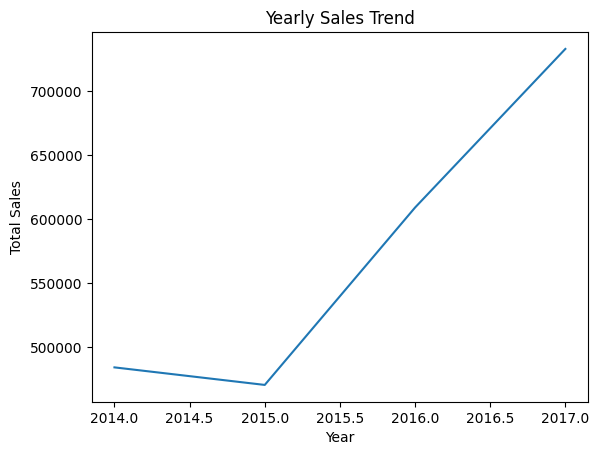

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(yearly_summary['Order Year'], yearly_summary['Sales'])
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

In [19]:
yearly_summary['Profit Margin'] = yearly_summary['Profit'] / yearly_summary['Sales']
yearly_summary

,Order Year,Sales,Profit,Profit Margin
0,2014,484247.4981,49543.9741,0.102311
1,2015,470532.5090,61618.6037,0.130955
2,2016,609205.5980,81795.1743,0.134265
3,2017,733215.2552,93439.2696,0.127438


In [20]:
monthly_summary = df.groupby('Order Month No').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

monthly_summary

,Order Month No,Sales,Profit
0,1,94924.8356,9134.4461
1,2,59751.2514,10294.6107
2,3,205005.4888,28594.6872
3,4,137762.1286,11587.4363
4,5,155028.8117,22411.3078
5,6,152718.6793,21285.7954
6,7,147238.0970,13832.6648
7,8,159044.0630,21776.9384
8,9,307649.9457,36857.4753
9,10,200322.9847,31784.0413


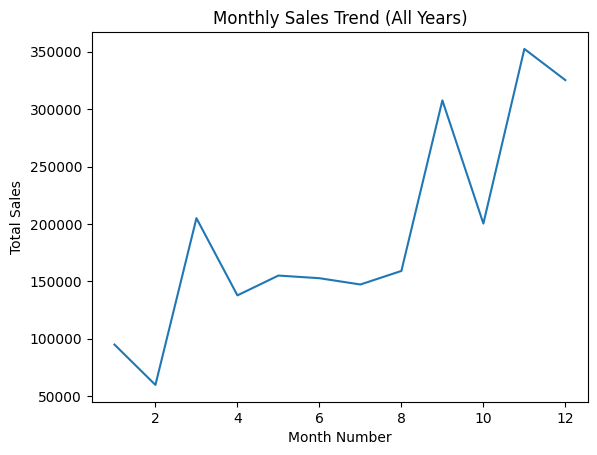

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_summary['Order Month No'], monthly_summary['Sales'])
plt.title("Monthly Sales Trend (All Years)")
plt.xlabel("Month Number")
plt.ylabel("Total Sales")
plt.show()

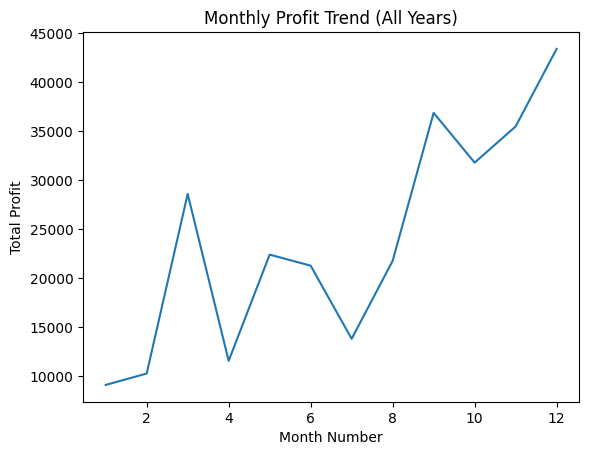

In [22]:
plt.figure()
plt.plot(monthly_summary['Order Month No'], monthly_summary['Profit'])
plt.title("Monthly Profit Trend (All Years)")
plt.xlabel("Month Number")
plt.ylabel("Total Profit")
plt.show()

In [23]:
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

region_summary['Profit Margin'] = region_summary['Profit'] / region_summary['Sales']

region_summary

,Region,Sales,Profit,Profit Margin
0,Central,501239.8908,39706.3625,0.079216
1,East,678781.2400,91522.7800,0.134834
2,South,391721.9050,46749.4303,0.119343
3,West,725457.8245,108418.4489,0.149448


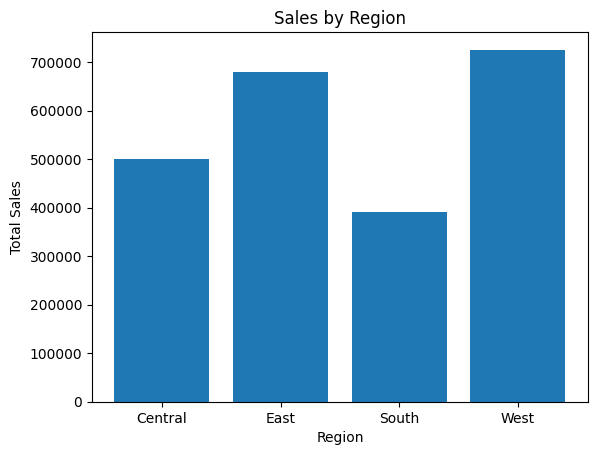

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(region_summary['Region'], region_summary['Sales'])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

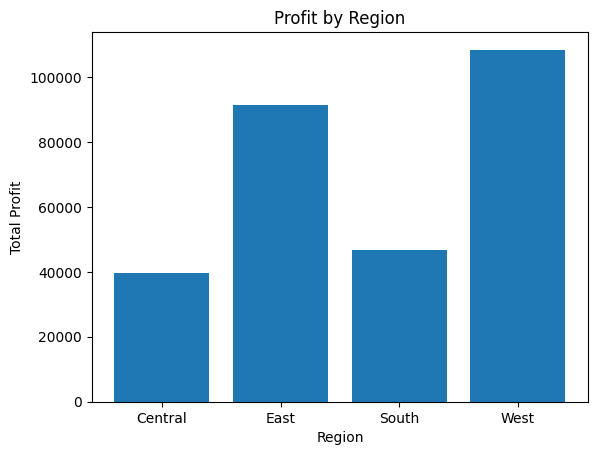

In [25]:
plt.figure()
plt.bar(region_summary['Region'], region_summary['Profit'])
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

In [26]:
category_summary = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

category_summary['Profit Margin'] = category_summary['Profit'] / category_summary['Sales']

category_summary

,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,0.024867
1,Office Supplies,719047.0320,122490.8008,0.170352
2,Technology,836154.0330,145454.9481,0.173957


In [27]:
subcategory_summary = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

subcategory_summary['Profit Margin'] = subcategory_summary['Profit'] / subcategory_summary['Sales']

subcategory_summary.sort_values(by='Profit', ascending=False)

,Sub-Category,Sales,Profit,Profit Margin
6,Copiers,149528.0300,55617.8249,0.371956
13,Phones,330007.0540,44515.7306,0.134893
0,Accessories,167380.3180,41936.6357,0.250547
12,Paper,78479.2060,34053.5693,0.433918
3,Binders,203412.7330,30221.7633,0.148574
5,Chairs,328449.1030,26590.1663,0.080957
14,Storage,223843.6080,21278.8264,0.095061
1,Appliances,107532.1610,18138.0054,0.168675
9,Furnishings,91705.1640,13059.1436,0.142404
7,Envelopes,16476.4020,6964.1767,0.422676


In [28]:
df[['Sales', 'Profit', 'Discount']].corr()

,Sales,Profit,Discount
Sales,1.000000,0.479064,-0.028190
Profit,0.479064,1.000000,-0.219487
Discount,-0.028190,-0.219487,1.000000


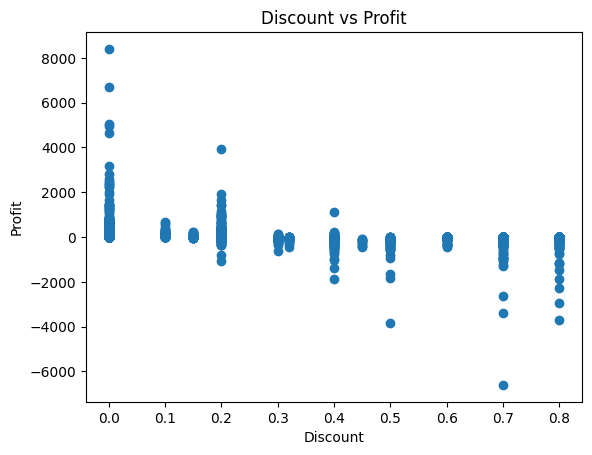

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [30]:
segment_summary = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

segment_summary['Profit Margin'] = segment_summary['Profit'] / segment_summary['Sales']

segment_summary

,Segment,Sales,Profit,Profit Margin
0,Consumer,1.161401e+06,134119.2092,0.115481
1,Corporate,7.061464e+05,91979.1340,0.130255
2,Home Office,4.296531e+05,60298.6785,0.140343


In [31]:
segment_discount = df.groupby('Segment')['Discount'].mean().reset_index()
segment_discount

,Segment,Discount
0,Consumer,0.158141
1,Corporate,0.158228
2,Home Office,0.147128


In [32]:
df.to_csv('../data/cleaned/cleaned_superstore.csv', index=False)

In [34]:
df.to_csv('../data/cleaned/cleaned_superstore.csv', index=False)